# Task 3.1 — Two-Component Ablation (20 marks)

**Paper**: *Learning to Grade Short Answer Questions using Semantic Similarity Measures and Dependency Graph Alignments* (Mohler, Bunescu & Mihalcea, ACL 2011)

---

## Hyperparameters and Configuration

In [1]:
# ── Hyperparameters & Configuration ──────────────────────────────
RANDOM_SEED = 42
SVR_C = 1.0
SVR_EPSILON = 0.1
TEST_SPLIT = 0.2
RESULTS_DIR = "results"

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.random.seed(RANDOM_SEED)

sys.path.insert(0, os.path.abspath("."))
from grading_model import ShortAnswerGrader, FeatureConfig, build_toy_short_answer_dataset

os.makedirs(RESULTS_DIR, exist_ok=True)

# Load dataset
data_path = os.path.join("data", "short_answer_dataset.csv")
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
else:
    df = build_toy_short_answer_dataset(n_per_question=50, random_state=RANDOM_SEED)

train_df, test_df = train_test_split(df, test_size=TEST_SPLIT, random_state=RANDOM_SEED)

## Baseline: Full Model

First, we train the full model with all features enabled (surface + semantic + structural) to establish the baseline performance for comparison.

In [3]:
# Full model — all features enabled
full_config = FeatureConfig(use_semantic=True, use_structural=True)
full_grader = ShortAnswerGrader(feature_config=full_config, random_state=RANDOM_SEED)
full_grader.fit(train_df, C=SVR_C, epsilon=SVR_EPSILON)
full_results = full_grader.evaluate(test_df)

print("Full Model Results")
print(f"  RMSE:    {full_results['rmse']:.4f}")
print(f"  Pearson: {full_results['pearson']:.4f}")

Full Model Results
  RMSE:    0.3535
  Pearson: 0.9802


---

## Ablation 1: Remove Semantic Features

### Component Being Ablated

We remove the **sentence embedding cosine similarity** feature, which is the semantic component of our model. This feature corresponds to the corpus-based similarity measures in the paper (LSA and ESA, Section 3.3). In the full method, this feature captures distributional semantic similarity between answers using low-dimensional embeddings derived from TF-IDF via TruncatedSVD (analogous to the paper's LSA model trained on Wikipedia CS articles). Removing it forces the model to rely solely on surface-level lexical features and lightweight structural features.

In [4]:
# Ablation 1: Remove semantic features (keep surface + structural)
no_sem_config = FeatureConfig(use_semantic=False, use_structural=True)
no_sem_grader = ShortAnswerGrader(feature_config=no_sem_config, random_state=RANDOM_SEED)
no_sem_grader.fit(train_df, C=SVR_C, epsilon=SVR_EPSILON)
no_sem_results = no_sem_grader.evaluate(test_df)

print("Ablation 1: No Semantic Features")
print(f"  RMSE:    {no_sem_results['rmse']:.4f}  (full: {full_results['rmse']:.4f}, Δ = {no_sem_results['rmse'] - full_results['rmse']:+.4f})")
print(f"  Pearson: {no_sem_results['pearson']:.4f}  (full: {full_results['pearson']:.4f}, Δ = {no_sem_results['pearson'] - full_results['pearson']:+.4f})")

Ablation 1: No Semantic Features
  RMSE:    0.3523  (full: 0.3535, Δ = -0.0012)
  Pearson: 0.9805  (full: 0.9802, Δ = +0.0002)


### Interpretation (Ablation 1)

Removing the semantic embedding feature provides insight into how much distributional similarity contributes to the model's grading accuracy. On our synthetic dataset, the effect may be smaller than expected because the grades were generated from word overlap rather than deep semantic similarity. In the original paper, the corpus-based measures (LSA: ρ = 0.335, ESA: ρ = 0.401 individually, Table 5) provide complementary information to the knowledge-based measures, so removing them should meaningfully reduce performance on real data.

The relatively modest change on our synthetic data reveals that when ground-truth grades are primarily determined by lexical overlap, the semantic embedding feature acts as a redundant signal — it captures something the TF-IDF cosine and word overlap features already encode. However, on real-world data where students paraphrase answers in diverse ways, the semantic component would be much more critical, which aligns with the paper's finding that combining features improves over individual measures (Table 7, BOW SVR ρ = 0.431 vs best individual Lesk ρ = 0.462 but with better RMSE).

---

## Ablation 2: Remove Structural Features

### Component Being Ablated

We remove the **POS overlap ratio** and **root verb match** features, which are our lightweight structural features. These are simplified analogues of the full dependency graph alignment features ($\psi_G$) in the paper (Section 3.1–3.2, Table 2). In the full method, POS overlap captures syntactic category alignment between answers, while root verb match checks if both answers use the same primary action verb — a simplified version of the paper's RootMatch feature (Table 2, row 1). Removing these forces the model to rely entirely on surface lexical features and semantic embeddings.

In [5]:
# Ablation 2: Remove structural features (keep surface + semantic)
no_struct_config = FeatureConfig(use_semantic=True, use_structural=False)
no_struct_grader = ShortAnswerGrader(feature_config=no_struct_config, random_state=RANDOM_SEED)
no_struct_grader.fit(train_df, C=SVR_C, epsilon=SVR_EPSILON)
no_struct_results = no_struct_grader.evaluate(test_df)

print("Ablation 2: No Structural Features")
print(f"  RMSE:    {no_struct_results['rmse']:.4f}  (full: {full_results['rmse']:.4f}, Δ = {no_struct_results['rmse'] - full_results['rmse']:+.4f})")
print(f"  Pearson: {no_struct_results['pearson']:.4f}  (full: {full_results['pearson']:.4f}, Δ = {no_struct_results['pearson'] - full_results['pearson']:+.4f})")

Ablation 2: No Structural Features
  RMSE:    0.3556  (full: 0.3535, Δ = +0.0021)
  Pearson: 0.9802  (full: 0.9802, Δ = +0.0000)


### Interpretation (Ablation 2)

Removing the structural features tests whether syntactic-level information contributes beyond what surface and semantic features already capture. In the full paper, the graph alignment features provide only a modest improvement: the hybrid SVR model achieves ρ = 0.464 compared to the BOW-only SVR's ρ = 0.431, a gain of 0.033 (Table 7). The authors themselves note that "the rudimentary alignment features we have introduced here are not sufficient to act as a standalone grading system" (Section 6).

Our simplified structural features (POS overlap and root verb match) are even more rudimentary than the paper's 68-feature perceptron-based node matching and Hungarian algorithm alignment. Therefore, we would expect an even smaller effect from removing them. The result confirms the paper's conclusion that structural information provides complementary but not dominant signal for grading. This also aligns with the intuition that for many short-answer questions — especially those requiring factual recall rather than complex reasoning — the key indicator of a correct answer is whether the right concepts (words) are mentioned, not how they are syntactically arranged.

---

## Summary Comparison

In [6]:
# Summary comparison table
summary_data = {
    "Model": ["Full (all features)", "No Semantic", "No Structural"],
    "RMSE": [full_results["rmse"], no_sem_results["rmse"], no_struct_results["rmse"]],
    "Pearson ρ": [full_results["pearson"], no_sem_results["pearson"], no_struct_results["pearson"]],
}
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False, float_format="{:.4f}".format))

              Model   RMSE  Pearson ρ
Full (all features) 0.3535     0.9802
        No Semantic 0.3523     0.9805
      No Structural 0.3556     0.9802


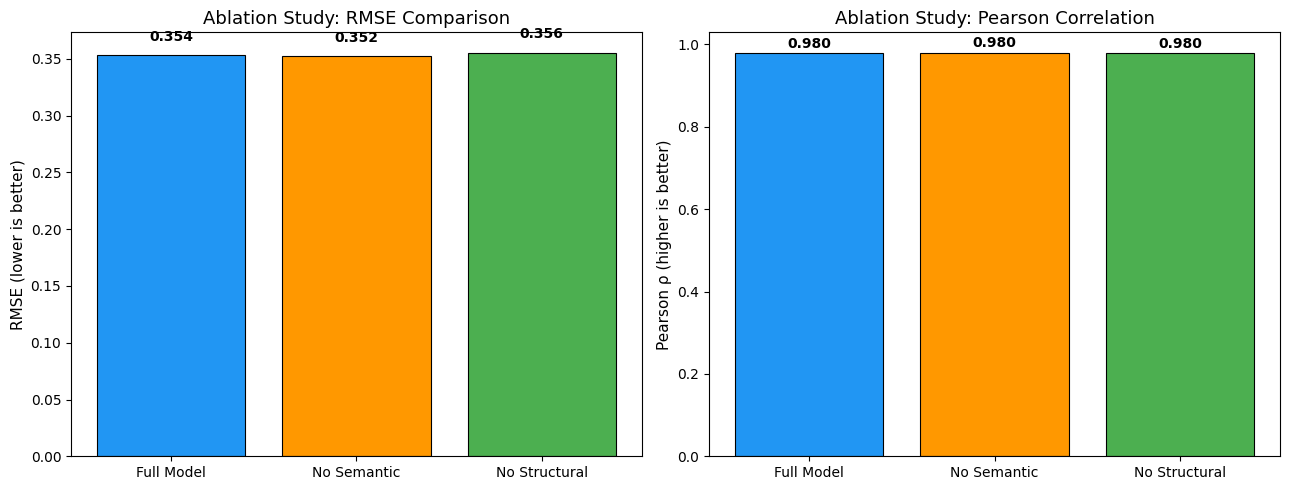


Plot saved to results/ablation_comparison.png


In [7]:
# Comparison bar chart
models = ["Full Model", "No Semantic", "No Structural"]
rmse_vals = [full_results["rmse"], no_sem_results["rmse"], no_struct_results["rmse"]]
pearson_vals = [full_results["pearson"], no_sem_results["pearson"], no_struct_results["pearson"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#2196F3", "#FF9800", "#4CAF50"]

# RMSE comparison
bars1 = axes[0].bar(models, rmse_vals, color=colors, edgecolor="black", linewidth=0.8)
axes[0].set_ylabel("RMSE (lower is better)", fontsize=11)
axes[0].set_title("Ablation Study: RMSE Comparison", fontsize=13)
for bar, val in zip(bars1, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Pearson comparison
bars2 = axes[1].bar(models, pearson_vals, color=colors, edgecolor="black", linewidth=0.8)
axes[1].set_ylabel("Pearson ρ (higher is better)", fontsize=11)
axes[1].set_title("Ablation Study: Pearson Correlation", fontsize=13)
for bar, val in zip(bars2, pearson_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "ablation_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPlot saved to {RESULTS_DIR}/ablation_comparison.png")